In [1]:
import os
import numpy as np
import pandas as pd
#import scanpy as sc
#import pyranges as pr
import warnings
pd.options.mode.chained_assignment = None  # default='warn'
import fnmatch

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

import seaborn as sns

from scipy.stats import gaussian_kde
from scipy import stats
# from tabulate import tabulate
# from sklearn.decomposition import PCA
import os
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
# from sklearn.cluster import KMeans


In [3]:
# Path to the directory containing color_palettes.py
import sys
home_dir = os.path.expanduser("~")

# Add the module directory to sys.path
sys.path.append(home_dir)

# Import the module
import color_palettes
from color_palettes import get_colormap

In [4]:
%matplotlib inline
# figure size & color
matplotlib.rcParams['figure.dpi'] = 100 # 150 dpi resolution
matplotlib.rcParams['image.cmap'] = 'Spectral_r' # preferred color map
matplotlib.rcParams['figure.figsize'] = [8, 8] # Square
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


# no bounding boxes or axis:
matplotlib.rcParams['axes.spines.bottom'] = "on"
matplotlib.rcParams['axes.spines.top'] = "on"
matplotlib.rcParams['axes.spines.left'] = "on"
matplotlib.rcParams['axes.spines.right'] = "on"
warnings.filterwarnings(action="ignore", module="matplotlib", message="findfont")

In [5]:
font = {#'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 15}

matplotlib.rc('font', **font)
matplotlib.rcParams['axes.linewidth'] = 2 #set the value globally

In [6]:
fig_dir = 'figures/'


# Peakprint 50 Slope fingerprints

In [464]:
bins = pd.read_csv("data/2024/SH_all_data/peakPRINT_50/MERGED_downsampled_bins.tsv", 
                   header = 0, 
                      index_col=False, 
                   sep='\t')
bins['dataset'] = bins['source_file'].str.split('_', expand=True)[0] + '_' + bins['source_file'].str.split('_', expand=True)[1]
bins['epitope'] = bins['source_file'].str.split('_', expand=True)[0]
bins['celltype'] = bins['source_file'].str.split('_', expand=True)[1]
bins.head()

,chr,start,end,coverage,rank,cumsum,source_file,dataset,epitope,celltype
0,chr1,0,50,0.000000,1.557600e-08,0.000000,K27ac_H_no_chrM_100pct.1-1000.bedGraph_downsam...,K27ac_H,K27ac,H
1,chr1,122671950,122672000,13.606536,9.999000e-01,0.997052,K27ac_H_no_chrM_100pct.1-1000.bedGraph_downsam...,K27ac_H,K27ac,H
2,chr14_GL000225v1_random,6800,6850,10.142265,9.998000e-01,0.995918,K27ac_H_no_chrM_100pct.1-1000.bedGraph_downsam...,K27ac_H,K27ac,H
3,chr11,71787000,71787050,8.946956,9.997000e-01,0.994981,K27ac_H_no_chrM_100pct.1-1000.bedGraph_downsam...,K27ac_H,K27ac,H
4,chr17_KI270729v1_random,1000,1050,8.285240,9.996000e-01,0.994131,K27ac_H_no_chrM_100pct.1-1000.bedGraph_downsam...,K27ac_H,K27ac,H


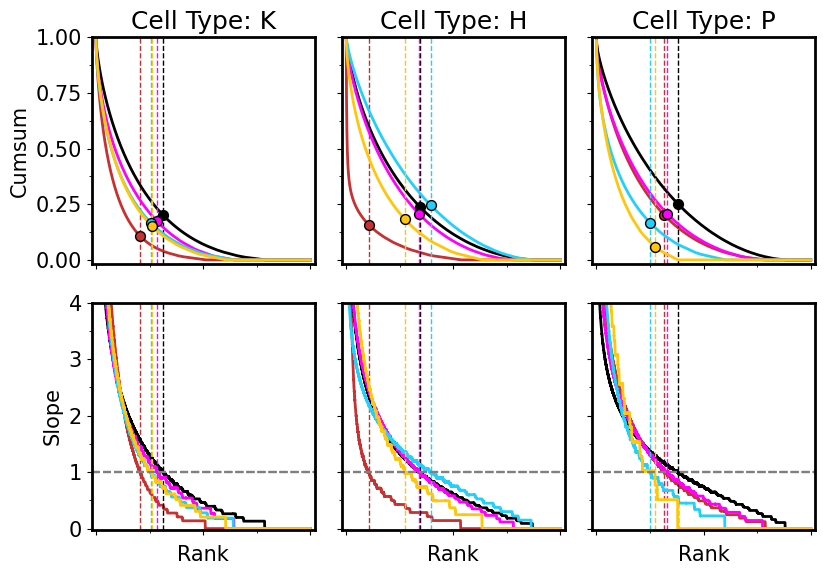

In [466]:
# Create a figure with 3 rows (one per plot type)
fig, axs = plt.subplots(2, 3, figsize=(8.5, 6), sharex='col', sharey='row')
# Define colors and hue order
cell_types = ['K','H','P']
hue_order = ['K27me3', 'K27me2', "K27me1", "K27ac", "P2"]
palette = ['#C73131', '#000000', '#FF00FF', '#22D0FB', '#FFC60B']

# Loop through each cell type and create subplots in corresponding columns
for col, cell_type in enumerate(cell_types):
    df_filtered = bins[bins['celltype'] == cell_type]

    for epitope, color in zip(hue_order, palette):
        df_epitope = df_filtered[df_filtered['epitope'] == epitope].sort_values(by='rank')
        # Compute first derivative (slope)
        df_epitope['first_derivative'] = np.gradient(df_epitope['cumsum'], df_epitope['rank'])
        df_epitope['rank'] = 1 - df_epitope['rank']
        
        # Find the index where slope is closest to 1
        idx_closest = (df_epitope['first_derivative'] - 1).abs().idxmin()
        x_slope_1 = df_epitope.loc[idx_closest, 'rank']
        y_slope_1 = df_epitope.loc[idx_closest, 'cumsum']

        # Plot original cumulative sum (Row 1)
        sns.lineplot(data=df_epitope, x='rank', y='cumsum', color=color, linewidth=2, ax=axs[0, col])
        axs[0, col].scatter(x_slope_1, y_slope_1, color=color, edgecolor='black', zorder=3, s=50)
        axs[0, col].axvline(x=x_slope_1, color=color, linestyle='--', linewidth=1)  # <--- ADD THIS

        axs[0, col].set_ylim(-0.02,1)
        axs[0, col].set_xlim(-0.02,1.02)
        axs[0, col].yaxis.set_minor_locator(MultipleLocator(0.125))
        
        # Plot first derivative (Row 2)
        sns.lineplot(data=df_epitope, x='rank', y='first_derivative', color=color, linewidth=2, ax=axs[1, col])
        axs[1, col].axvline(x=x_slope_1, color=color, linestyle='--', linewidth=1)  # <--- ADD THIS
        
        axs[1, col].set_ylim(-0.02,4)
        axs[1, col].set_xlim(-0.02,1.02)
        axs[1, col].yaxis.set_minor_locator(MultipleLocator(0.5))
        axs[1, col].axhline(y=1, ls='--', c='grey')

    # Set titles and labels
    axs[0, col].set_title(f'Cell Type: {cell_type}')
    axs[1, col].set_xlabel("Rank")

# Set row labels
axs[0, 0].set_ylabel("Cumsum")
axs[1, 0].set_ylabel("Slope")

# Apply detailed grid to all subplots
for row in axs:
    for ax in row:
        # ax.minorticks_on()
        # ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
        # Grid settings
        # ax.xaxis.set_major_locator(MultipleLocator(0.2))  # major ticks every 100 (optional)
        ax.xaxis.set_minor_locator(MultipleLocator(.25))   # minor ticks every 10
        # ax.grid(True, which='both', axis='y')
        ax.set_xticklabels('')


# Adjust layout for better spacing
plt.tight_layout()
# Save the figure
plt.savefig(
    fig_dir + '250411_K27_HKP_fingerprint_peakPRINT_50_slope.pdf',
    transparent=True,
    bbox_inches='tight',
    #facecolor = 'black'
)
# Show the plot
plt.show()


# min300 coverage

In [479]:
min300_df = pd.read_csv("data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/downsample_peakPRINT_slope1_min350_meta_v1.tsv", 
                   header = 0, 
                      index_col=False, 
                   sep='\t')
min300_df

,BedFileName,PercentSampled,NumberOfReads,GenomeCovered,FractionOfReadsInPeaks,nPeaks,avg_Peakwidth,Peakwidths
0,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,10,9347225,36.48,0.8314,1622573,741.78,NaN
1,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,13,12151392,43.93,0.8798,1738489,833.61,NaN
2,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,16,14955560,22.24,0.6382,1110866,660.74,NaN
3,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,19,17759727,27.57,0.7065,1275524,713.20,NaN
4,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,1,934722,3.65,0.3819,250946,480.58,NaN
...,...,...,...,...,...,...,...,...
504,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,118977234,18.01,0.8775,353882,1679.29,NaN
505,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,129602619,26.41,0.7679,712997,1222.37,NaN
506,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,63110325,20.29,0.7458,704903,949.64,NaN
507,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,73921344,20.65,0.8071,544049,1252.33,NaN


In [480]:
min300_df = min300_df[min300_df['PercentSampled'] == 100]
min300_df

,BedFileName,PercentSampled,NumberOfReads,GenomeCovered,FractionOfReadsInPeaks,nPeaks,avg_Peakwidth,Peakwidths
494,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,93472250,31.42,0.7152,1133706,914.43,NaN
495,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,82876071,20.58,0.8007,563500,1205.02,NaN
496,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,77232965,18.58,0.7585,603897,1015.11,NaN
497,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,163740542,21.93,0.6096,1017793,711.03,NaN
498,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,119056852,15.40,0.6052,711425,714.10,NaN
499,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,135641782,20.52,0.5768,995156,680.31,NaN
500,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,162449715,27.88,0.7287,826437,1113.06,NaN
501,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,119947175,25.97,0.7659,759129,1128.65,NaN
502,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,147374679,29.35,0.6860,1084042,893.35,NaN
503,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,103423595,6.85,0.7994,194552,1161.86,NaN


In [481]:
min300_df['FileName'] = min300_df['BedFileName'].str.split('/', expand = True)[12]
min300_df['Epitope'] = min300_df['FileName'].str.split('_', expand = True)[0]
min300_df['Cell Type'] = min300_df['FileName'].str.split('_', expand = True)[1]
min300_df['Genome Fraction'] = min300_df['GenomeCovered']/100
min300_df

,BedFileName,PercentSampled,NumberOfReads,GenomeCovered,FractionOfReadsInPeaks,nPeaks,avg_Peakwidth,Peakwidths,FileName,Epitope,Cell Type,Genome Fraction
494,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,93472250,31.42,0.7152,1133706,914.43,NaN,K27ac_H_no_chrM.bed,K27ac,H,0.3142
495,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,82876071,20.58,0.8007,563500,1205.02,NaN,K27ac_K_no_chrM.bed,K27ac,K,0.2058
496,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,77232965,18.58,0.7585,603897,1015.11,NaN,K27ac_P_no_chrM.bed,K27ac,P,0.1858
497,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,163740542,21.93,0.6096,1017793,711.03,NaN,K27me1_H_no_chrM.bed,K27me1,H,0.2193
498,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,119056852,15.40,0.6052,711425,714.10,NaN,K27me1_K_no_chrM.bed,K27me1,K,0.1540
499,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,135641782,20.52,0.5768,995156,680.31,NaN,K27me1_P_no_chrM.bed,K27me1,P,0.2052
500,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,162449715,27.88,0.7287,826437,1113.06,NaN,K27me2_H_no_chrM.bed,K27me2,H,0.2788
501,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,119947175,25.97,0.7659,759129,1128.65,NaN,K27me2_K_no_chrM.bed,K27me2,K,0.2597
502,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,147374679,29.35,0.6860,1084042,893.35,NaN,K27me2_P_no_chrM.bed,K27me2,P,0.2935
503,/fh/fast/henikoff_s/user/jgreene/projects/H3K2...,100,103423595,6.85,0.7994,194552,1161.86,NaN,K27me3_H_no_chrM.bed,K27me3,H,0.0685


/loc/scratch/18092657/ipykernel_15682/306177164.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend().set_visible(False)
/loc/scratch/18092657/ipykernel_15682/306177164.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend().set_visible(False)


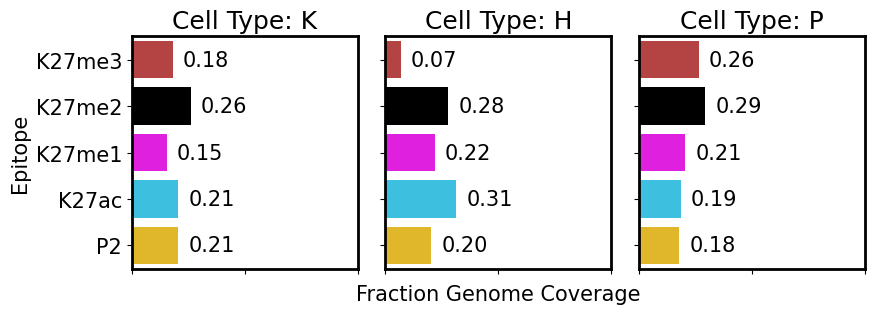

In [85]:
# Define colors and hue order
# cell_types = bins['celltype'].unique()
cell_types = ['K','H','P']
hue_order = ['K27me3', 'K27me2', "K27me1", "K27ac", "P2"]
palette = ['#C73131', '#000000', '#FF00FF', '#22D0FB', '#FFC60B']

# Convert to DataFrame
df_slope = pd.DataFrame(min300_df, columns=['Epitope', 'Cell Type', 'Genome Fraction'])

# Create the Seaborn bar plot for each cell type
fig, axs = plt.subplots(1, 3, figsize=(9, 3.4), sharex=True, sharey=True)

for i, cell_type in enumerate(cell_types):
    df_subset = df_slope[df_slope['Cell Type'] == cell_type]

    # Ensure the bars are sorted by genome fraction
    # df_subset = df_subset.sort_values(by='Genome Fraction', ascending=True)

    # Plot using Seaborn
    sns.barplot(
        data=df_subset,
        x='Genome Fraction',
        y='Epitope',
        hue='Epitope',  # Use hue to match colors
        hue_order = hue_order,
        order=hue_order,
        palette={epitope: color for epitope, color in zip(hue_order, palette)},
        dodge=False,
        ax=axs[i]
    )

# Reverse x-axis so bars start from the right
    axs[i].invert_xaxis()
    axs[i].set_xlim(0, 1)  # X-axis represents genome fraction (0 to 1)
    axs[i].set_title(f"Cell Type: {cell_type}")
    axs[i].set_xticklabels('')

    # Annotate each bar at the end
    for index, row in df_subset.iterrows():
        axs[i].text(
            row['Genome Fraction'] + 0.25,  # Adjusted for positioning (shift left)
            row['Epitope'],
            f"{row['Genome Fraction']:.2f}",
            color='black',
            va='center',
            ha='right'
        )
        
    if i == 1:
        axs[i].set_xlabel('Fraction Genome Coverage')
    else:
        axs[i].set_xlabel('')
        axs[i].legend().set_visible(False)

# Adjust layout for better spacing
plt.tight_layout()
# Save the figure
plt.savefig(
    fig_dir + '250411_K27_HKP_fingerprint_peakPRINT_50_slope_genomeCov_min300.pdf',
    transparent=True,
    bbox_inches='tight',
    #facecolor = 'black'
)
# Show the plot
plt.show()


In [190]:
corr_path = 'data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/reproducibility/FRiPs_merged_intervals_rep95.tsv'
corr = pd.read_csv(corr_path, sep='\t', header = 0)
corr['BedFile'] = corr['BedFile'].str[:-8]
# corr['PeakFile'] = corr['PeakFile'].str[:-48]
corr['PeakFile'] = corr['PeakFile'].str[:-23]


corr

,BedFile,PeakFile,TotalReads,TotalPeaks,ReadsInPeaks,FractionOfReadsInPeaks,PeaksetCoverage,RPKM
0,K27ac_P,K27ac_H,77232965,288820,22168632,0.287036,5.5922,51327900.0
1,K27ac_K,K27ac_H,82876071,288820,23258069,0.280637,5.5922,50183600.0
2,K27ac_H,K27ac_H,93472250,288820,22256036,0.238103,5.5922,42577700.0
3,K27me2_K,K27ac_H,119947175,288820,19871343,0.165667,5.5922,29624700.0
4,K27me1_K,K27ac_H,119056852,288820,29281679,0.245947,5.5922,43980400.0
...,...,...,...,...,...,...,...,...
220,K27me2_H,P2_P,162449715,207519,18224745,0.112187,4.1340,27137600.0
221,K27me2_P,P2_P,147374679,207519,10097314,0.068515,4.1340,16573400.0
222,P2_H,P2_P,63110325,207519,15417512,0.244295,4.1340,59094100.0
223,P2_K,P2_P,73921344,207519,21107731,0.285543,4.1340,69071800.0


In [191]:
corr['Peak_celltype'] = corr['PeakFile'].str[-1]
corr['Bed_celltype'] = corr['BedFile'].str[-1]
corr['Peak_epitope'] = corr['PeakFile'].str[:-2]
corr['Bed_epitope'] = corr['BedFile'].str[:-2]

corr[corr['Peak_celltype']==corr['Bed_celltype']]
corr

,BedFile,PeakFile,TotalReads,TotalPeaks,ReadsInPeaks,FractionOfReadsInPeaks,PeaksetCoverage,RPKM,Peak_celltype,Bed_celltype,Peak_epitope,Bed_epitope
0,K27ac_P,K27ac_H,77232965,288820,22168632,0.287036,5.5922,51327900.0,H,P,K27ac,K27ac
1,K27ac_K,K27ac_H,82876071,288820,23258069,0.280637,5.5922,50183600.0,H,K,K27ac,K27ac
2,K27ac_H,K27ac_H,93472250,288820,22256036,0.238103,5.5922,42577700.0,H,H,K27ac,K27ac
3,K27me2_K,K27ac_H,119947175,288820,19871343,0.165667,5.5922,29624700.0,H,K,K27ac,K27me2
4,K27me1_K,K27ac_H,119056852,288820,29281679,0.245947,5.5922,43980400.0,H,K,K27ac,K27me1
...,...,...,...,...,...,...,...,...,...,...,...,...
220,K27me2_H,P2_P,162449715,207519,18224745,0.112187,4.1340,27137600.0,P,H,P2,K27me2
221,K27me2_P,P2_P,147374679,207519,10097314,0.068515,4.1340,16573400.0,P,P,P2,K27me2
222,P2_H,P2_P,63110325,207519,15417512,0.244295,4.1340,59094100.0,P,H,P2,P2
223,P2_K,P2_P,73921344,207519,21107731,0.285543,4.1340,69071800.0,P,K,P2,P2


/loc/scratch/18092657/ipykernel_15682/3336815318.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(marks_order, rotation=90, horizontalalignment='right')
/loc/scratch/18092657/ipykernel_15682/3336815318.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(marks_order, rotation=90, horizontalalignment='right')
/loc/scratch/18092657/ipykernel_15682/3336815318.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(marks_order, rotation=90, horizontalalignment='right')


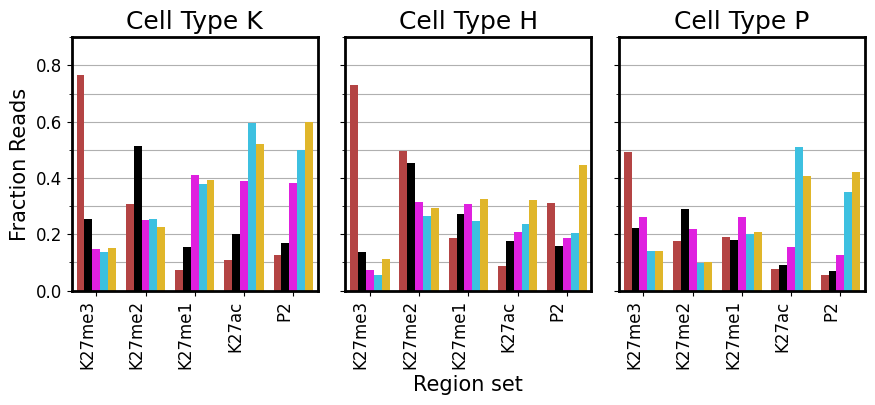

In [192]:
# Your file names
file_names = [
    'K27me3_H', 'K27me2_H', 'K27me1_H', 'K27ac_H', 'P2_H', 
    'K27me3_K', 'K27me2_K', 'K27me1_K', 'K27ac_K', 'P2_K', 
    'K27me3_P', 'K27me2_P', 'K27me1_P', 'K27ac_P', 'P2_P', 
]

# Assuming 'corr' is your DataFrame containing the relevant data
# Filter the DataFrame as per your condition
filtered_data = corr[corr['Peak_celltype'] == corr['Bed_celltype']]
filtered_data['PeakFile'] = pd.Categorical(filtered_data['PeakFile'], categories=file_names, ordered=True)
filtered_data = filtered_data.sort_values('PeakFile')

# Create a figure with 1 row and 3 columns for each cell type
fig, axes = plt.subplots(1, 3, figsize=(9, 4.3),  sharey=True)

# Define the palette
palette = ['#C73131', '#000000', '#FF00FF', '#22D0FB', '#FFC60B']

# Define the order of histone marks for the x-axis
marks_order = ['K27me3', 'K27me2', 'K27me1', 'K27ac', 'P2']

# Loop over each cell type and create its subplot
for i, cell_type_suffix in enumerate(['_K', '_H', '_P']):
    # Filter data for the current cell type
    cell_type_data = filtered_data[filtered_data['PeakFile'].str.endswith(cell_type_suffix)]
    
    # Correct the order of the 'PeakFile' column based on histone marks
    cell_type_data['PeakFile'] = cell_type_data['PeakFile'].str.replace(cell_type_suffix, '')
    cell_type_data['PeakFile'] = pd.Categorical(cell_type_data['PeakFile'], categories=marks_order, ordered=True)
    cell_type_data = cell_type_data.sort_values('PeakFile')
    
    # Create the barplot on the current axis
    sns.barplot(
        data=cell_type_data, 
        x="PeakFile", 
        y="FractionOfReadsInPeaks", 
        hue="Bed_epitope",
        hue_order=marks_order,
        legend = False,
        palette=palette,
        ax=axes[i]  # Plot in the i-th axis
    )
    
    # Set x-tick labels and title for the subplot
    axes[i].set_title(f'Cell Type {cell_type_suffix.strip("_")}')
    axes[i].set_ylim(top = 0.9)
    axes[i].yaxis.set_minor_locator(MultipleLocator(.1))  # major ticks every 100 (optional)
    axes[i].grid(True, which='both', axis='y')
    axes[i].set_axisbelow(True)
    axes[i].tick_params(axis='x', labelsize=12)
    axes[i].tick_params(axis='y', labelsize=12)
    axes[i].set_xlabel('Region set' if i == 1 else '')
    axes[i].set_ylabel('Fraction Reads' if i == 0 else '')
    axes[i].set_xticklabels(marks_order, rotation=90, horizontalalignment='right')

# Adjust the layout
plt.tight_layout()

# Save the figure
plt.savefig(
    fig_dir + '250412_FRIPs_HKP_merged_barplot_bycell_rep95.pdf',
    transparent=True,
    bbox_inches='tight'
)

# Show the plot
plt.show()


# Downsampling

In [378]:
dataset = pd.read_csv("data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/downsample_peakPRINT_slope1_min350_meta_v1.tsv", 
                   header = 0, 
                   sep='\t',
                 )
dataset1 = pd.read_csv("data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/downsample_peakPRINT_slope1_min350_meta_v2.tsv", 
                   header = 0,
                   sep='\t')
# dataset2 = pd.read_csv("data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/downsample_peakPRINT_slope1_min300_meta_v3.tsv", 
#                    header = 0, 
#                    sep='\t')
dataset = pd.concat([dataset,dataset1])
dataset
dataset.reset_index(inplace = True)

In [379]:
dataset['Filename'] = dataset['BedFileName'].str.split('/', expand=True)[12].str.split('.', expand=True)[0]
dataset['epitope'] = dataset['Filename'].str.split('_', expand=True)[0]
dataset['celltype'] = dataset['Filename'].str.split('_', expand=True)[1]

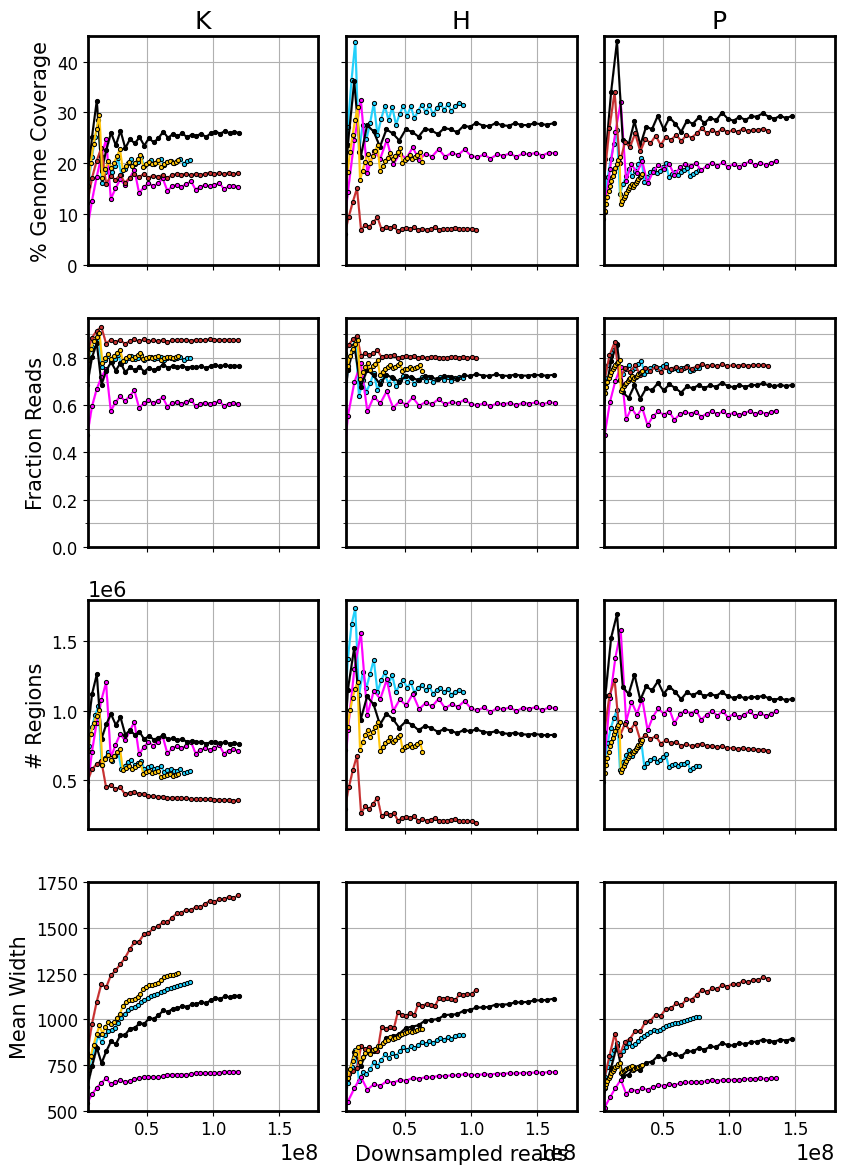

In [383]:
# Assuming 'dataset' is your DataFrame and 'fig_dir' is defined for saving the figure
selected_epitopes = ['K27ac', 'K27me1', 'K27me2', 'K27me3', 'P2']
selected_celltypes = ['K', 'H', 'P']
metrics = ['GenomeCovered', 'FractionOfReadsInPeaks', 'nPeaks', 'avg_Peakwidth']

# Filter dataset for selected celltypes and epitopes
plot_data = dataset[(dataset['celltype'].isin(selected_celltypes)) & (dataset['epitope'].isin(selected_epitopes))]

# Create a figure and a set of subplots
fig, axs = plt.subplots(len(metrics), len(selected_celltypes), figsize=(8.7, 12), sharex=True, sharey='row')
dot_markers = {epitope: '.' for epitope in selected_epitopes}
for i, metric in enumerate(metrics):
    for j, celltype in enumerate(selected_celltypes):
        ax = axs[i, j]
        data = plot_data[plot_data['celltype'] == celltype]
        sns.lineplot(data=data,
                        x='NumberOfReads',
                        y=metric,
                        hue='epitope',
                        style = 'epitope',
                        palette=['#22D0FB', '#FF00FF', '#000000', '#C73131', '#FFC60B'],
                        legend = False,
                        errorbar = 'ci',
                        markers=dot_markers,
                        markeredgecolor='black',    
                         markersize=6,
                         linewidth = 1.5,
                        dashes=False,
                         ax=ax
                    )
        ax.set_title(f'{celltype}' if i == 0 else '')
        # ax.set_xscale('log')
        ax.set_xlim(xmin = 5*10**6, xmax = 1.8*10**8)
        ax.grid(True)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        
        # Only show the legend for the first plot
        if i == 0:
            ax.set_ylim(ymin = 0,ymax = 45)
            ax.set_ylabel('% Genome Coverage' if j == 0 else '')
        if i == 1:
            ax.set_ylim(ymin = 0)
            ax.yaxis.set_minor_locator(MultipleLocator(.1))
            ax.grid(True, which='both', axis='y')
            ax.set_ylabel('Fraction Reads' if j == 0 else '')

        if i == 2:
            ax.set_ylim(ymin = .15*10**6, ymax = 6.05**8)
            ax.set_ylabel('# Regions' if j == 0 else '')
            
        if i == 3:
            ax.set_ylim(ymin = 500, ymax = 1750)
            ax.set_xlabel('Downsampled reads' if j == 1 else '')
            ax.set_ylabel('Mean Width' if j == 0 else '')


# Adjust the layout
plt.tight_layout()

# Save the figure
plt.savefig(
    fig_dir + '250414_downsampled_coverage_min350.pdf',
    transparent=True,
    bbox_inches='tight',
    #facecolor = 'black'
)

plt.show()


# Rank peaks

In [7]:
def read_bed(file_path):
    """Read a BED file and return a DataFrame."""
    columns = ['chr', 'start', 'end', 'sum', 'mean']
    df = pd.read_csv(file_path, sep='\t', header=None, names=columns, usecols=[0, 1, 2,3,4])
    return df

def compute_interval_metrics(df):
    """Compute interval size and distance to the next interval."""
    df['interval_size'] = df['end'] - df['start']
    df['distance_to_next'] = df['start'].shift(-1) - df['end']
    df.loc[df.index[-1], 'distance_to_next'] = np.nan  # Set NaN for the last interval
    return df

def downsample_bed(df, n=10000):
    """Downsample the BED file to n entries."""
    if len(df) > n:
        df = df.sample(n=n, random_state=42).sort_index()
    return df

def process_bed_files(directory, pattern):
    """Process all BED files matching a pattern in the specified directory and return merged DataFrames."""
    interval_sizes = []
    distances_to_next = []

    for filename in os.listdir(directory):
        if fnmatch.fnmatch(filename, pattern):
            file_path = os.path.join(directory, filename)
            df = read_bed(file_path)
            df = compute_interval_metrics(df)
            # df = df[df['interval_size'] > 300]
            # df = downsample_bed(df)
            
            df['file_name'] = filename
            df['dataset'] = df['file_name'].str.split('_', expand=True)[0] + '_' + df['file_name'].str.split('_', expand=True)[1]
            df['epitope'] = df['file_name'].str.split('_', expand=True)[0]
            df['celltype'] = df['file_name'].str.split('_', expand=True)[1]
            
            interval_sizes.append(df[['chr', 'start', 'end', 'sum', 'mean','interval_size','distance_to_next', 'file_name','dataset','epitope', 'celltype']])

    interval_size_df = pd.concat(interval_sizes, ignore_index=True)

    return interval_size_df

In [8]:
# Specify the directory containing the BED files and the pattern to match
input_directory = 'data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/'
# pattern = '*_reproducibility_95plus.bed'  # Example pattern to match files with '_filtered.bed'
pattern = 'K27me3_K_peak_coverage.bed'
# Process the BED files and get merged DataFrames
interval_size_df = process_bed_files(input_directory, pattern)

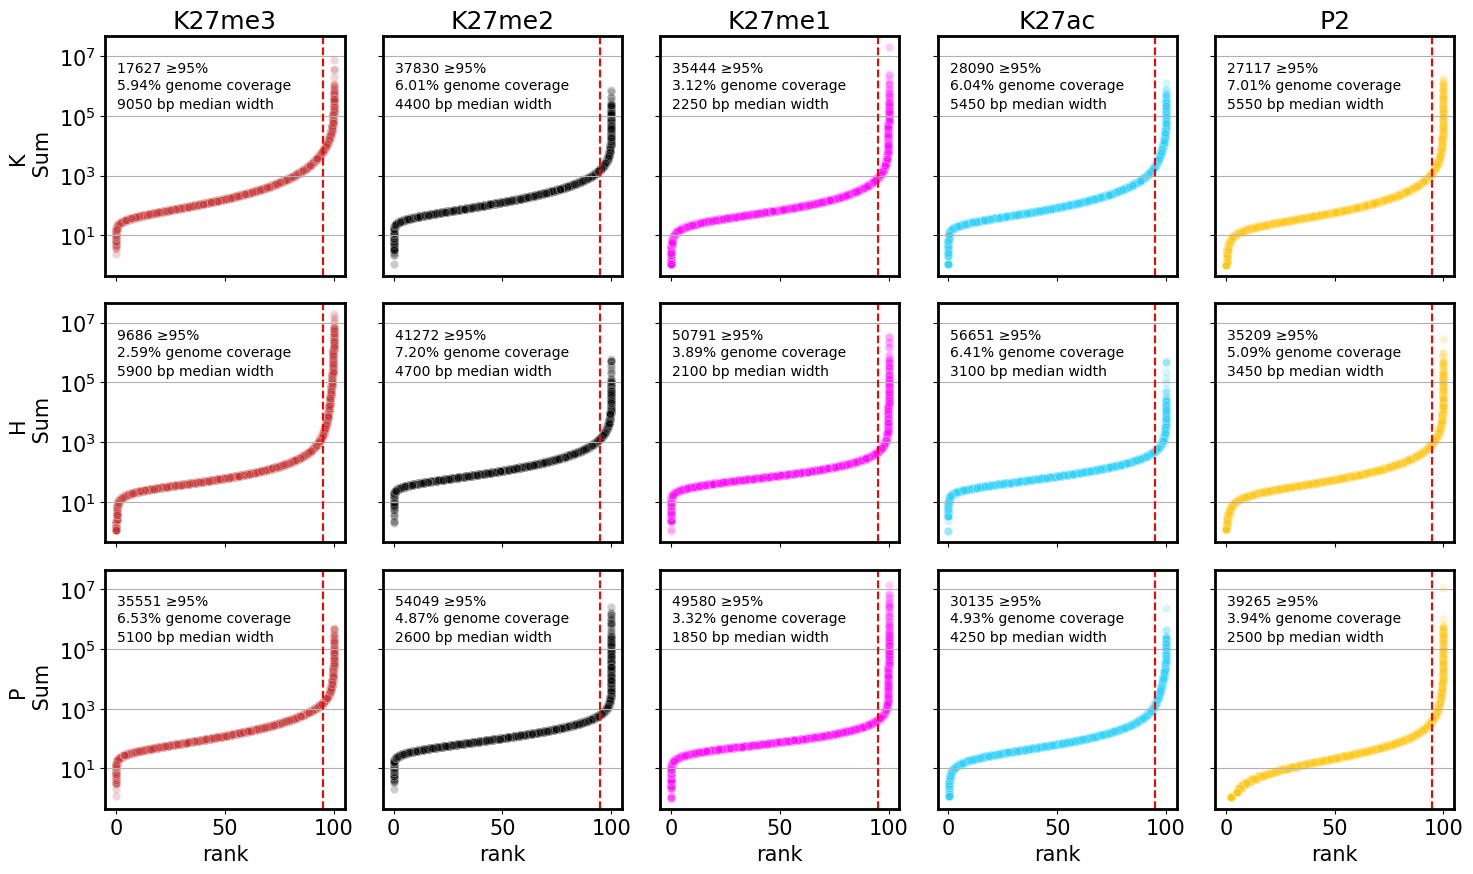

In [12]:
import os

# Define the desired order of epitopes
epitope_order = ["K27me3", "K27me2", "K27me1", "K27ac", "P2"]
celltype_order = ["K", "H", "P"]

# Define custom colors for each epitope
epitope_colors = {
    "K27me3": "#C73131",  # Red
    "K27me2": "#000000",  # Black
    "K27me1": "#FF00FF",  # Magenta
    "K27ac": "#22D0FB",   # Blue
    "P2": "#FFC60B"       # Yellow
}

# Filter the dataset to include only specified epitopes in order
df = interval_size_df
df_filtered = df[df["epitope"].isin(epitope_order) & df["celltype"].isin(celltype_order)]
df_filtered["epitope"] = pd.Categorical(df_filtered["epitope"], categories=epitope_order, ordered=True)
df_filtered["celltype"] = pd.Categorical(df_filtered["celltype"], categories=celltype_order, ordered=True)


#remove non_standard chr
mask = df_filtered['chr'].str.match(r"^chr(?:[1-9]|1[0-9]|2[0-2]|X|Y)$")
df_filtered = df_filtered[mask].copy()

# Create subplots: 2D grid (cell type rows, epitope columns)
fig, axes = plt.subplots(len(celltype_order), len(epitope_order), figsize=(15, 9), sharex=True, sharey=True)

# Plot each epitope in a separate subplot
for i, celltype in enumerate(celltype_order):
    for j, epitope in enumerate(epitope_order):
        subset = df_filtered[(df_filtered["epitope"] == epitope) & (df_filtered["celltype"] == celltype)]
        subset['rank'] = subset['sum'].rank()/len(subset)*100

        ax = axes[i, j]

        # Scatter plot
        sns.scatterplot(data=subset, x="rank", y="sum", alpha=0.2, ax=ax, color=epitope_colors[epitope], rasterized=True,)
        ax.set_yscale('log')
        ax.axvline(x=95, c='red', ls='--')
        ax.grid(True, which='major', axis='y')

        # Annotate with the fraction of peaks at reproducibility >= 95
        up95 = subset[subset["rank"] >= 95]
        fraction_95 = len(up95)
        ax.annotate(f"{fraction_95} ≥95%", xy=(0.05, 0.85), xycoords="axes fraction", fontsize=10, color="black")
        cov = up95['interval_size'].sum() / 3298912062
        ax.annotate(f"{cov:.2%} genome coverage", xy=(0.05, 0.78), xycoords="axes fraction", fontsize=10, color="black")
        width = up95['interval_size'].median()
        ax.annotate(f"{width:.0f} bp median width", xy=(0.05, 0.7), xycoords="axes fraction", fontsize=10, color="black")

        os.makedirs("data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/top95",
                    exist_ok=True)
        up95.sort_values(by = 'interval_size',ascending = False ).to_csv(f"data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/top95/{epitope}_{celltype}_top95regions.bed", 
                        sep='\t', index=False, header = False, columns = ['chr','start','end','rank']
                       )

        # Set labels and titles
        if i == 0:
            ax.set_title(epitope)
        if j == 0:
            ax.set_ylabel(f"{celltype} \n Sum")

plt.tight_layout()
# Save the figure
plt.savefig(
    fig_dir + '250412_ranked_regions_min350.pdf',
    transparent=True,
    bbox_inches='tight'
)

# Show the plot
plt.show()

In [284]:
frip_path = 'data/2024/ENCODE_chromHMM/FRIPs.tsv'
FRIPS = pd.read_csv(frip_path, sep='\t', header = 0)
FRIPS['Mark'] = FRIPS['BedFile'].str[:-10]
FRIPS['Celltype'] = FRIPS['BedFile'].str[-9]
FRIPS['ChromHMM_celltype'] = FRIPS['PeakFile'].str.split('_',expand = True)[0].str[0]
FRIPS['ChromHMM_nMarks'] = FRIPS['PeakFile'].str.split('_',expand = True)[2]
FRIPS['ChromHMM_state'] = FRIPS['PeakFile'].str.split('_hg38lift_mnemonics_', expand = True)[1]

FRIPS.head()

,BedFile,PeakFile,TotalReads,TotalPeaks,ReadsInPeaks,FractionOfReadsInPeaks,PeaksetCoverage,RPKM,Mark,Celltype,ChromHMM_celltype,ChromHMM_nMarks,ChromHMM_state
0,K27ac_K_no_chrM,H1_E003_15_coreMarks_hg38lift_mnemonics_10_TssBiv,82876071,9131,804984,0.009713,0.2162,44926500.0,K27ac,K,H,15,10_TssBiv
1,K27ac_P_no_chrM,H1_E003_15_coreMarks_hg38lift_mnemonics_10_TssBiv,77232965,9131,1228515,0.015907,0.2162,73573500.0,K27ac,P,H,15,10_TssBiv
2,K27ac_H_no_chrM,H1_E003_15_coreMarks_hg38lift_mnemonics_10_TssBiv,93472250,9131,272540,0.002916,0.2162,13486300.0,K27ac,H,H,15,10_TssBiv
3,K27me1_K_no_chrM,H1_E003_15_coreMarks_hg38lift_mnemonics_10_TssBiv,119056852,9131,444552,0.003734,0.2162,17270800.0,K27me1,K,H,15,10_TssBiv
4,K27me2_K_no_chrM,H1_E003_15_coreMarks_hg38lift_mnemonics_10_TssBiv,119947175,9131,477607,0.003982,0.2162,18417300.0,K27me2,K,H,15,10_TssBiv


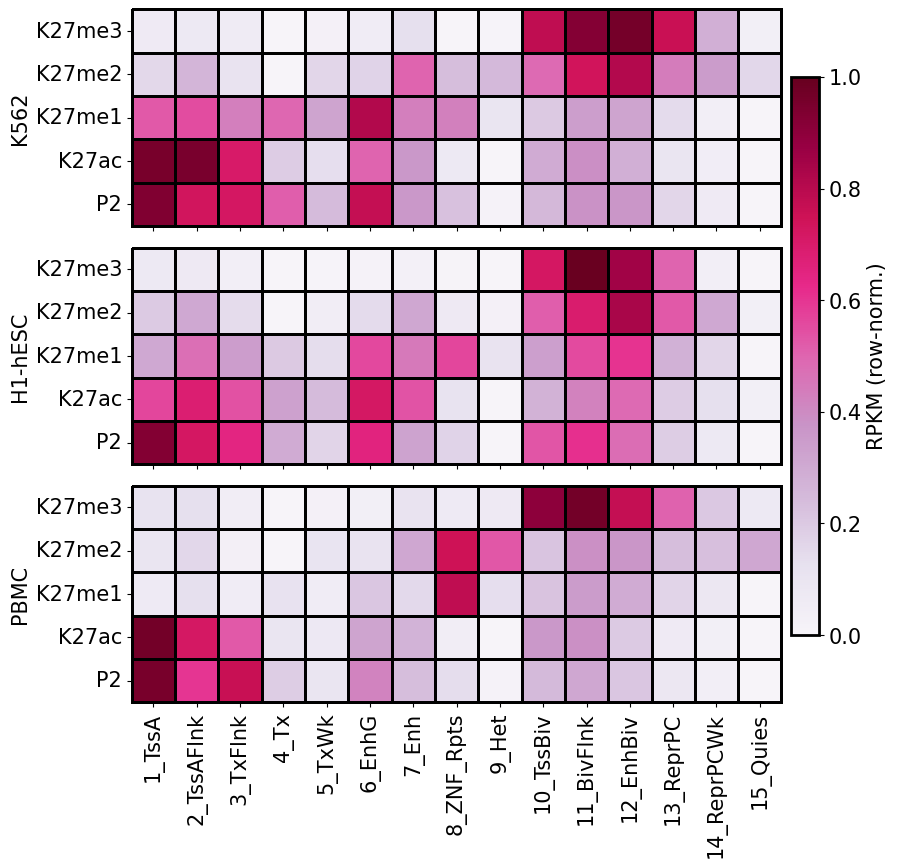

In [285]:
wide = (
    FRIPS[FRIPS["ChromHMM_nMarks"] == "15"]
    .pivot_table(
        index=["Celltype","Mark"],
        columns="ChromHMM_state",
        values="RPKM",
        aggfunc="mean"
    )
    .reset_index()
)
state_cols = [c for c in wide.columns if isinstance(c,str) and c[0].isdigit()]
state_cols = sorted(state_cols, key=lambda s: int(s.split("_",1)[0]))
ct_map = {"H":"H1-hESC", "K":"K562", "P":"PBMC"}
mark_order = ["K27me3","K27me2","K27me1","K27ac","P2"]

# ── Create a 3×1 set of heatmap axes ─────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=True,
    gridspec_kw=dict(
        height_ratios=[1, 1, 1],
        hspace=0.1
    )
)

# ── Draw each heatmap, disabling its individual colorbar ────────────────────
for ax, code in zip(axes, ["K", "H", "P"]):
    df_ct = (
        wide[wide["Celltype"] == code]
          .set_index("Mark")
          .reindex(mark_order)
    )
    df_states = df_ct[state_cols]
    norm = (
        df_states
        .subtract(df_states.min(axis=1), axis=0)
        .div(df_states.max(axis=1), axis=0)
        .fillna(0)
    )
    sns.heatmap(
        norm,
        ax=ax,
        cmap="PuRd",
        vmin=0,
        vmax=1,
        cbar=False,
        linewidths=2, 
        linecolor='black', 
        square=True, 
        # fmt=".2f", 
        clip_on=False
    )
    ax.set_ylabel(ct_map[code])
    ax.set_xlabel("")

# ── Shared, slim colorbar hugging the heatmaps ──────────────────────────────
sm = ScalarMappable(cmap="PuRd", norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(
    sm,
    ax=axes,                # apply to all three heatmap axes
    orientation="vertical",
    fraction=0.03,          # thickness of the bar
    pad=0.01,               # distance from heatmaps
    label="RPKM (row-norm.)"
)
plt.savefig(
    fig_dir + '250418_mark_chromHMM_15state_RPKM.png',
    transparent=True,
    bbox_inches='tight'
)
plt.show()


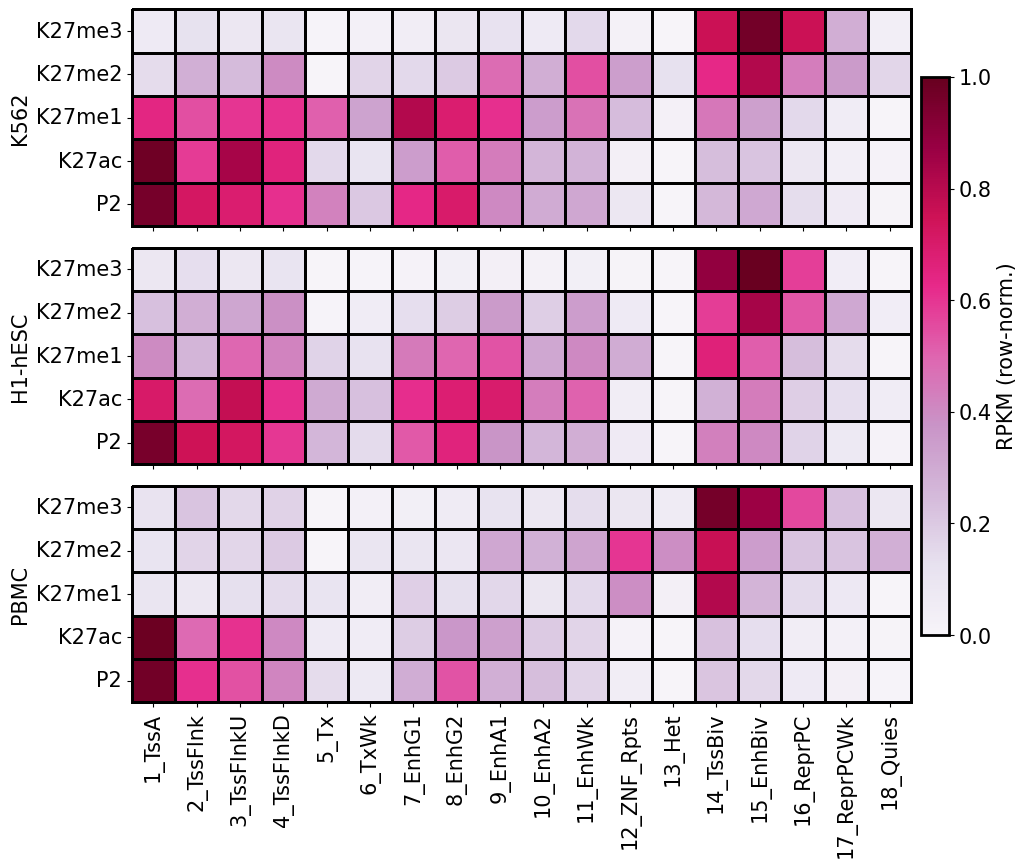

In [286]:
wide = (
    FRIPS[FRIPS["ChromHMM_nMarks"] == "18"]
    .pivot_table(
        index=["Celltype","Mark"],
        columns="ChromHMM_state",
        values="RPKM",
        aggfunc="mean"
    )
    .reset_index()
)
state_cols = [c for c in wide.columns if isinstance(c,str) and c[0].isdigit()]
state_cols = sorted(state_cols, key=lambda s: int(s.split("_",1)[0]))
ct_map = {"H":"H1-hESC", "K":"K562", "P":"PBMC"}
mark_order = ["K27me3","K27me2","K27me1","K27ac","P2"]

# ── Create a 3×1 set of heatmap axes ─────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=True,
    gridspec_kw=dict(
        height_ratios=[1, 1, 1],
        hspace=0.1
    )
)

# ── Draw each heatmap, disabling its individual colorbar ────────────────────
for ax, code in zip(axes, ["K", "H", "P"]):
    df_ct = (
        wide[wide["Celltype"] == code]
          .set_index("Mark")
          .reindex(mark_order)
    )
    df_states = df_ct[state_cols]
    norm = (
        df_states
        .subtract(df_states.min(axis=1), axis=0)
        .div(df_states.max(axis=1), axis=0)
        .fillna(0)
    )
    sns.heatmap(
        norm,
        ax=ax,
        cmap="PuRd",
        vmin=0,
        vmax=1,
        cbar=False,
        linewidths=2, 
        linecolor='black', 
        square=True, 
        # fmt=".2f", 
        clip_on=False
    )
    ax.set_ylabel(ct_map[code])
    ax.set_xlabel("")

# ── Shared, slim colorbar hugging the heatmaps ──────────────────────────────
sm = ScalarMappable(cmap="PuRd", norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(
    sm,
    ax=axes,                # apply to all three heatmap axes
    orientation="vertical",
    fraction=0.03,          # thickness of the bar
    pad=0.01,               # distance from heatmaps
    label="RPKM (row-norm.)"
)
plt.savefig(
    fig_dir + '250418_mark_chromHMM_18state_RPKM.png',
    transparent=True,
    bbox_inches='tight'
)
plt.show()


In [541]:
frip_path = 'data/2024/ENCODE_chromHMM/OverlapEnrichments.tsv'
FRIPS = pd.read_csv(frip_path, sep='\t', header = None)
FRIPS.columns = ['BedFile','PeakFile','Overlap_Enrichment']
FRIPS['Mark_Celltype'] = FRIPS['BedFile'].str[:-52]
FRIPS['Mark'] = FRIPS['Mark_Celltype'].str[:-2]
FRIPS['Celltype'] = FRIPS['Mark_Celltype'].str[-1]
FRIPS['ChromHMM_celltype'] = FRIPS['PeakFile'].str.split('_',expand = True)[0].str[0]
FRIPS['ChromHMM_nMarks'] = FRIPS['PeakFile'].str.split('_',expand = True)[2]
FRIPS['ChromHMM_state'] = FRIPS['PeakFile'].str.split('_hg38lift_mnemonics_', expand = True)[1].str[:-4]

FRIPS.head()

,BedFile,PeakFile,Overlap_Enrichment,Mark_Celltype,Mark,Celltype,ChromHMM_celltype,ChromHMM_nMarks,ChromHMM_state
0,K27ac_H_no_chrM_100pct.1-1000.bedGraph_merged_...,H1_E003_15_coreMarks_hg38lift_mnemonics_10_Tss...,0.6953,K27ac_H,K27ac,H,H,15,10_TssBiv
1,K27ac_H_no_chrM_100pct.1-1000.bedGraph_merged_...,H1_E003_15_coreMarks_hg38lift_mnemonics_11_Biv...,1.0105,K27ac_H,K27ac,H,H,15,11_BivFlnk
2,K27ac_H_no_chrM_100pct.1-1000.bedGraph_merged_...,H1_E003_15_coreMarks_hg38lift_mnemonics_12_Enh...,1.1882,K27ac_H,K27ac,H,H,15,12_EnhBiv
3,K27ac_H_no_chrM_100pct.1-1000.bedGraph_merged_...,H1_E003_15_coreMarks_hg38lift_mnemonics_13_Rep...,0.6346,K27ac_H,K27ac,H,H,15,13_ReprPC
4,K27ac_H_no_chrM_100pct.1-1000.bedGraph_merged_...,H1_E003_15_coreMarks_hg38lift_mnemonics_14_Rep...,1.1386,K27ac_H,K27ac,H,H,15,14_ReprPCWk


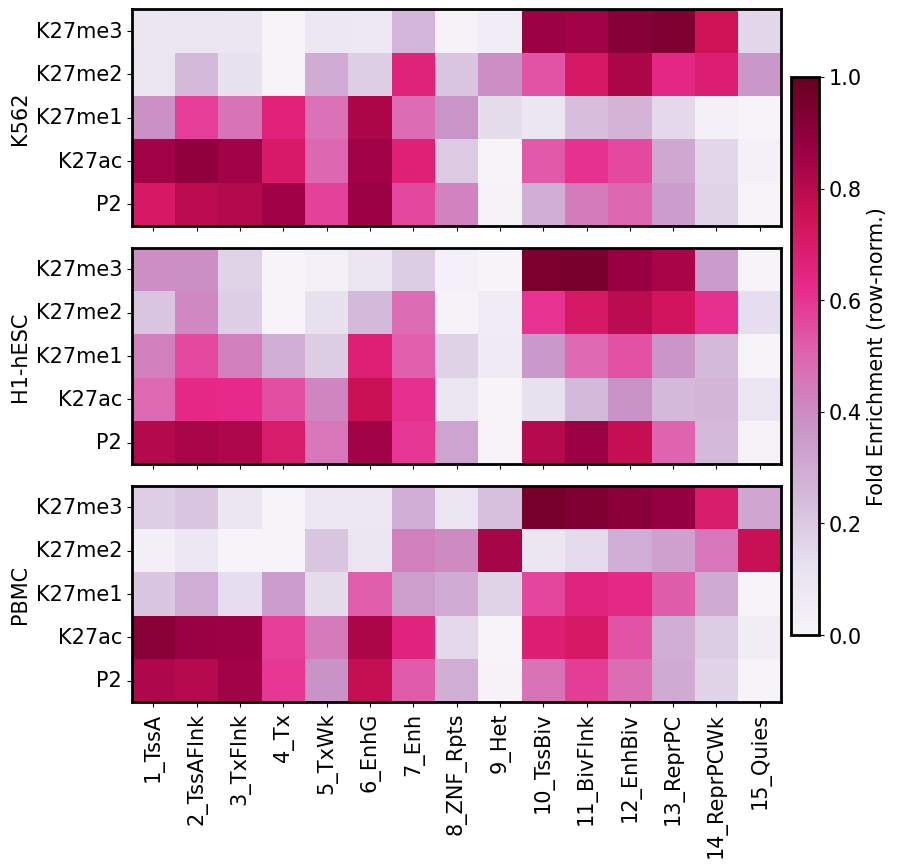

In [304]:
wide = (
    FRIPS[FRIPS["ChromHMM_nMarks"] == "15"]
    .pivot_table(
        index=["Celltype","Mark"],
        columns="ChromHMM_state",
        values="Overlap_Enrichment",
        aggfunc="mean"
    )
    .reset_index()
)
state_cols = [c for c in wide.columns if isinstance(c,str) and c[0].isdigit()]
state_cols = sorted(state_cols, key=lambda s: int(s.split("_",1)[0]))
ct_map = {"H":"H1-hESC", "K":"K562", "P":"PBMC"}
mark_order = ["K27me3","K27me2","K27me1","K27ac","P2"]

# ── Create a 3×1 set of heatmap axes ─────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=True,
    gridspec_kw=dict(
        height_ratios=[1, 1, 1],
        hspace=0.1
    )
)

# ── Draw each heatmap, disabling its individual colorbar ────────────────────
for ax, code in zip(axes, ["K", "H", "P"]):
    df_ct = (
        wide[wide["Celltype"] == code]
          .set_index("Mark")
          .reindex(mark_order)
    )
    df_states = df_ct[state_cols]
    norm = (
        df_states
        .subtract(df_states.min(axis=1), axis=0)
        .div(df_states.max(axis=1), axis=0)
        .fillna(0)
    )
    sns.heatmap(
        norm,
        ax=ax,
        cmap="PuRd",
        vmin=0,
        vmax=1,
        cbar=False,
        linewidths=0, 
        linecolor='black', 
        square=True, 
        # fmt=".2f", 
        clip_on=False
    )
    ax.set_ylabel(ct_map[code])
    ax.set_xlabel("")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

# ── Shared, slim colorbar hugging the heatmaps ──────────────────────────────
sm = ScalarMappable(cmap="PuRd", norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(
    sm,
    ax=axes,                # apply to all three heatmap axes
    orientation="vertical",
    fraction=0.03,          # thickness of the bar
    pad=0.01,               # distance from heatmaps
    label="Fold Enrichment (row-norm.)"
)
plt.savefig(
    fig_dir + '250418_mark_chromHMM_15state_Overlap_Enrichment.pdf',
    transparent=True,
    bbox_inches='tight'
)
plt.show()


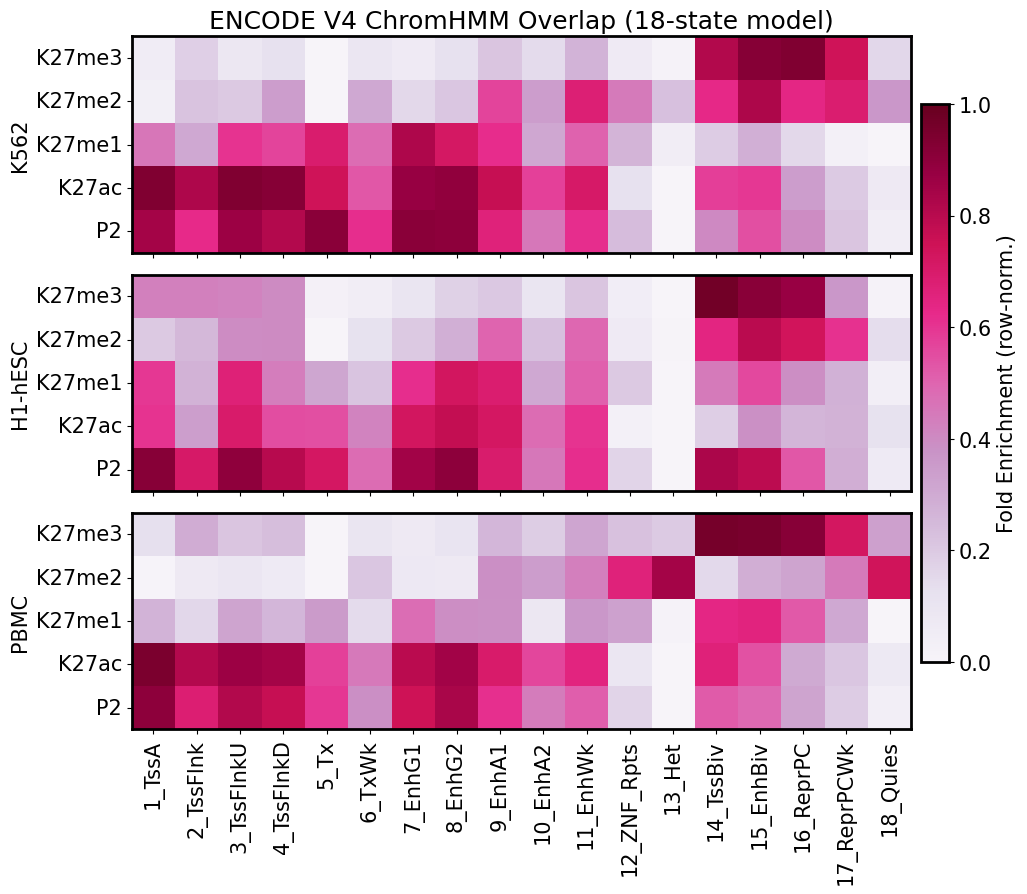

In [543]:
wide = (
    FRIPS[FRIPS["ChromHMM_nMarks"] == "18"]
    .pivot_table(
        index=["Celltype","Mark"],
        columns="ChromHMM_state",
        values="Overlap_Enrichment",
        aggfunc="mean"
    )
    .reset_index()
)
state_cols = [c for c in wide.columns if isinstance(c,str) and c[0].isdigit()]
state_cols = sorted(state_cols, key=lambda s: int(s.split("_",1)[0]))
ct_map = {"H":"H1-hESC", "K":"K562", "P":"PBMC"}
mark_order = ["K27me3","K27me2","K27me1","K27ac","P2"]

# ── Create a 3×1 set of heatmap axes ─────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=True,
    gridspec_kw=dict(
        height_ratios=[1, 1, 1],
        hspace=0.1
    )
)

# ── Draw each heatmap, disabling its individual colorbar ────────────────────
for ax, code in zip(axes, ["K", "H", "P"]):
    df_ct = (
        wide[wide["Celltype"] == code]
          .set_index("Mark")
          .reindex(mark_order)
    )
    df_states = df_ct[state_cols]
    norm = (
        df_states
        .subtract(df_states.min(axis=1), axis=0)
        .div(df_states.max(axis=1), axis=0)
        .fillna(0)
    )
    sns.heatmap(
        norm,
        ax=ax,
        cmap="PuRd",
        vmin=0,
        vmax=1,
        cbar=False,
        linewidths=0, 
        linecolor='black', 
        square=True, 
        # fmt=".2f", 
        clip_on=False
    )
    ax.set_ylabel(ct_map[code])
    ax.set_xlabel("")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

    if code == 'K':
        ax.set_title('ENCODE V4 ChromHMM Overlap (18-state model)')
    else:
        ax.set_title('')
    
# ── Shared, slim colorbar hugging the heatmaps ──────────────────────────────
sm = ScalarMappable(cmap="PuRd", norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(
    sm,
    ax=axes,                # apply to all three heatmap axes
    orientation="vertical",
    fraction=0.03,          # thickness of the bar
    pad=0.01,               # distance from heatmaps
    label="Fold Enrichment (row-norm.)"
)
plt.savefig(
    fig_dir + '250418_mark_chromHMM_18state_Overlap_Enrichment.pdf',
    transparent=True,
    bbox_inches='tight'
)
plt.show()


In [347]:
frip_path = 'data/2024/cCREs/intersected_annos/FRIPs.tsv'
FRIPS = pd.read_csv(frip_path, sep='\t', header = 0)
FRIPS['Mark_Celltype'] = FRIPS['BedFile'].str[:-8]
FRIPS['Mark'] = FRIPS['Mark_Celltype'].str[:-2]
FRIPS['Celltype'] = FRIPS['Mark_Celltype'].str[-1]
FRIPS['annoType'] = FRIPS['PeakFile'].str.split('.',expand = True)[0]
FRIPS['anno_subClass'] = FRIPS['PeakFile'].str.split('clean',expand = True)[1].str[1:]
# FRIPS['ChromHMM_celltype'] = FRIPS['PeakFile'].str.split('_',expand = True)[0].str[0]
# FRIPS['ChromHMM_nMarks'] = FRIPS['PeakFile'].str.split('_',expand = True)[2]
# FRIPS['ChromHMM_state'] = FRIPS['PeakFile'].str.split('_hg38lift_mnemonics_', expand = True)[1].str[:-4]

FRIPS.head()

,BedFile,PeakFile,TotalReads,TotalPeaks,ReadsInPeaks,FractionOfReadsInPeaks,PeaksetCoverage,RPKM,Mark_Celltype,Mark,Celltype,annoType,anno_subClass
0,K27ac_K_no_chrM,genes.noPromoters,82876071,29830,48784539,0.588644,41.0799,14329200.0,K27ac_K,K27ac,K,genes,None
1,K27ac_P_no_chrM,genes.noPromoters,77232965,29830,44473692,0.575838,41.0799,14017500.0,K27ac_P,K27ac,P,genes,None
2,K27ac_H_no_chrM,genes.noPromoters,93472250,29830,49545779,0.530059,41.0799,12903100.0,K27ac_H,K27ac,H,genes,None
3,K27me1_K_no_chrM,genes.noPromoters,119056852,29830,67915500,0.570446,41.0799,13886300.0,K27me1_K,K27me1,K,genes,None
4,K27me2_K_no_chrM,genes.noPromoters,119947175,29830,52270206,0.435777,41.0799,10608000.0,K27me2_K,K27me2,K,genes,None


In [356]:
FRIPS['annoType'].unique()

array(['genes', 'GRCh38-cCREs', 'H1_allCCREs', 'K562_allCCREs',
       'promoters', 'rmsk'], dtype=object)

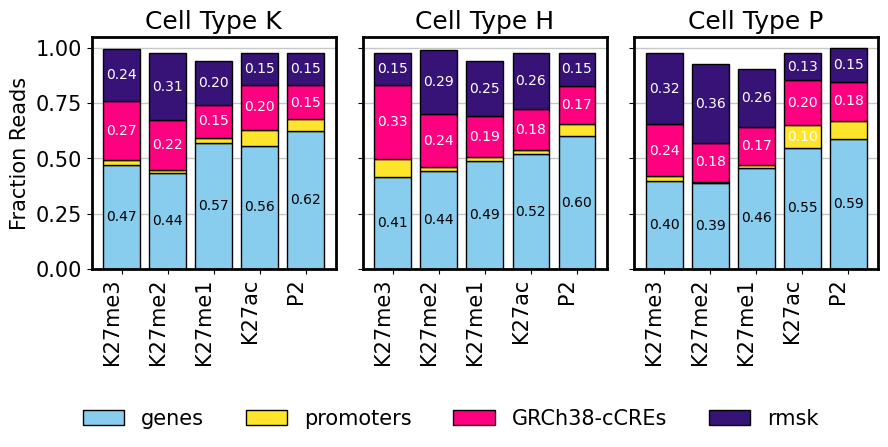

In [538]:
cell_types   = ['K','H','P']
marks_order  = ['K27me3','K27me2','K27me1','K27ac','P2']
anno_order   = ['genes','promoters','GRCh38-cCREs','rmsk']
region_colors = ["#88CCEE", "#FEE52C", "#ff0080",'#371377']#get_colormap(set_name="ironMan", palette_type="discrete", num_categories=20, reverse=False, convert_to_hex=True)#sns.color_palette("Accent", n_colors=len(anno_order))

# ─── SET UP FIGURE ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharey=True)

for ax, ct in zip(axes, cell_types):
    # 1) subset & filter
    df_ct = FRIPS[FRIPS['Celltype'] == ct]
    df_ct = df_ct[df_ct['annoType'].isin(anno_order)]
    
    # 2) aggregate sums per Mark × annoType
    agg = (
        df_ct
        .groupby(['Mark','annoType'], as_index=False)['FractionOfReadsInPeaks']
        .sum()
    )
    
    # 3) pivot to wide form
    pivot = (
        agg
        .pivot(index='Mark', columns='annoType', values='FractionOfReadsInPeaks')
        .reindex(index=marks_order, columns=anno_order)
        .fillna(0)
    )
    
    row_sums = pivot.sum(axis=1)
    mask     = row_sums > 1
    pivot.loc[mask] = pivot.loc[mask].div(row_sums[mask]*1.02, axis=0)
    # 4) plot stacked bars
    pivot.plot(
        kind      = 'bar',
        stacked   = True,
        ax        = ax,
        color     = region_colors,
        edgecolor = 'black',
        width     = 0.8,
        legend    = False
    )
# ─── annotate any segment > 0.1 ─────────────────────────────────────────
    # compute cumulative bottoms so we know where each segment starts
    cum_bottom = np.zeros(len(pivot))
    for j, anno in enumerate(pivot.columns):
        heights = pivot[anno].values
        centers = cum_bottom + heights / 2

        # choose black text for 'genes', white otherwise
        text_color = 'black' if anno == 'genes' else 'white'

        for i, h in enumerate(heights):
            if h > 0.1:
                ax.text(
                    i, centers[i],
                    f"{h:.2f}",
                    ha='center', va='center',
                    color=text_color,
                    fontsize=10
                )
        cum_bottom += heights
    
    # 5) cosmetics
    ax.set_title(f'Cell Type {ct}')
    ax.set_ylabel('')
    ax.set_xlabel('')
    if ax is axes[0]:
        ax.set_ylabel('Fraction Reads')
    ax.set_xticklabels(marks_order, rotation=90, ha='right')
    ax.grid(axis='y', linewidth=1, alpha=0.7)
    ax.set_axisbelow(True)

# gather handles & labels from any one Axes
handles, labels = axes[-1].get_legend_handles_labels()

# place one shared legend below all plots
fig.legend(
    handles, labels,
    title='',
    ncol=4,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    frameon=False
)

# make room at the bottom
plt.subplots_adjust(bottom=0.18)

plt.tight_layout()
plt.savefig(
    fig_dir + '250418_annoType_FRIPs.pdf',
    transparent=True,
    bbox_inches='tight'
)
plt.show()

/loc/scratch/18092657/ipykernel_20637/2221596004.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['anno_subClass','Mark'], as_index=False)['RPKM']
/loc/scratch/18092657/ipykernel_20637/2221596004.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/loc/scratch/18092657/ipykernel_20637/2221596004.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(anno_order, rotation=90, ha='right', fontsize=10)
/loc/scratch/18092657/ipykernel_20637/2221596004.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obse

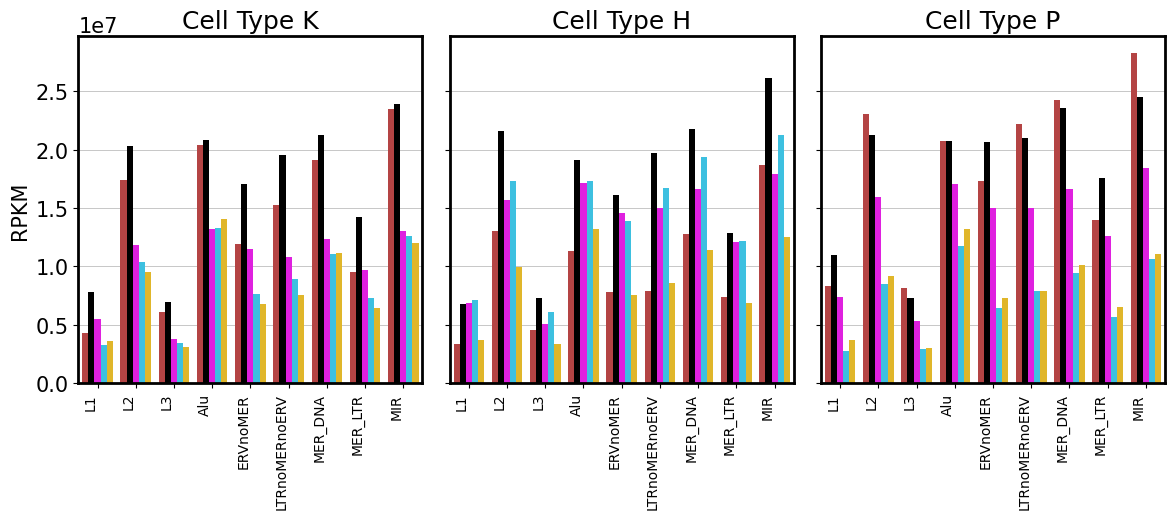

In [446]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ─── CONFIG ────────────────────────────────────────────────────────────────────
palette     = ['#C73131','#000000','#FF00FF','#22D0FB','#FFC60B']
marks_order = ['K27me3','K27me2','K27me1','K27ac','P2']
cell_types  = ['K','H','P']
anno_order = [ 'L1', 'L2', 'L3','Alu', 'ERVnoMER','LTRnoMERnoERV', 'MER_DNA',
       'MER_LTR', 'MIR']

# ─── MAKE THE FIGURE ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 5.45), sharey=True)

for ax, cell_type in zip(axes, cell_types):
    # 1) subset
    df_ct = FRIPS[FRIPS['annoType'] == 'rmsk'].copy()
    df_ct = df_ct[df_ct['Celltype'] == cell_type]

    # 2) force Mark ordering
    df_ct['Mark'] = pd.Categorical(df_ct['Mark'], categories=marks_order, ordered=True)

    # 3) aggregate sums per annoType × Mark
    agg = (
        df_ct
        .groupby(['anno_subClass','Mark'], as_index=False)['RPKM']
        .sum()
    )

    # 5) draw the barplot
    sns.barplot(
        data      = agg,
        x         = 'anno_subClass',
        y         = 'RPKM',
        hue       = 'Mark',
        hue_order = marks_order,
        palette   = palette,
        order     = anno_order,
        ax        = ax,
        ci        = None,     # sums are deterministic, no CI needed
        legend = False
    )

    # 6) labels, ticks, grid
    ax.set_title(f'Cell Type {cell_type}')
    ax.set_xticklabels(anno_order, rotation=90, ha='right', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('RPKM')
    else:
        ax.set_ylabel('')
    ax.set_xlabel('')
    ax.yaxis.set_minor_locator(MultipleLocator(0.5*10**7))
    ax.grid(True, which='both', axis='y', lw=0.5)
    ax.set_axisbelow(True)

# 7) put a single legend on the rightmost subplot
# axes[-1].legend(
#     title='Mark',
#     bbox_to_anchor=(1.05, 1),
#     loc='upper left'
# )

plt.tight_layout()
plt.savefig(
    fig_dir + '250418_repeats_RPKM.pdf',
    transparent=True,
    bbox_inches='tight'
)
plt.show()


In [435]:
agg['anno_subClass'].unique()

array(['Alu', 'ERVnoMER', 'L1', 'L2', 'L3', 'LTRnoMERnoERV', 'MER_DNA',
       'MER_LTR', 'MIR'], dtype=object)